In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [3]:
# recall & qps on dynamic datasets
# on SIFT/MSTuring dynamic sets
# surge & gp-ann
# 
# surge - to generate:
# ./bin/shared_batch_experiment_sweep

# gp-ann - to generate:
# 1. python extract_first_batch.py
# 2. ./Partition - partitions on first batch
# 3. mv partitions ->partitions.local (only for shift?)
# 3. offset_partition.py partitions.local -> partitions (only for shift?)
# 2. ./DistributedInsertBenchSweep

In [4]:
def read_postgres_results(json_paths):
    """
    Read JSONL (JSON Lines) files from run_streaming_runbook.py into a pandas DataFrame.
    
    Args:
        json_paths: str or list of str
            Path(s) to JSONL result file(s) from run_streaming_runbook.py.
            Each line in the file is a JSON object.
    
    Returns:
        pd.DataFrame
            DataFrame with columns from the JSON records. The first row is
            typically a header record with type="initialization".
    """
    import json
    
    # Normalize input to list
    if isinstance(json_paths, str):
        json_paths = [json_paths]
    
    records = []
    
    for json_path in json_paths:
        try:
            with open(json_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        try:
                            record = json.loads(line)
                            records.append(record)
                        except json.JSONDecodeError as e:
                            print(f"Warning: Failed to parse JSON line in {json_path}: {e}")
                            continue
        except FileNotFoundError:
            print(f"Warning: File not found: {json_path}")
            continue
    
    if not records:
        print("No records found in the provided JSON files.")
        return pd.DataFrame()
    
    df = pd.DataFrame(records)
    return df


In [5]:
def remove_weird_throughput_measurements_gpann(df, nprobe):
    subset = df[df["nprobe"] == nprobe]
    if len(subset) <= 1:
        return df
    max_throughput = subset["qps_or_throughput"].max()
    min_throughput = subset["qps_or_throughput"].min()
    if max_throughput > 1.5 * min_throughput:
        # remove the smaller one
        df = df.drop(subset[subset["qps_or_throughput"] == min_throughput].index)
    return df

In [6]:
def remove_duplicate_steps(df):
    # df = df.sort_values(by=["step", "operation"], ascending=[True, True])
    # df = df.drop_duplicates(subset=["step"], keep="last")
    # return df
    # ^ dropped all the steps that has multiple search entries
    # drop only is the step, operation, param, mode are the same
    df = df.sort_values(by=["step", "operation", "param", "mode"], ascending=[True, True, True, True])
    df = df.drop_duplicates(subset=["step", "operation", "param", "mode"], keep="last")
    return df

In [7]:
def remove_weird_throughput_measurements(df, mode, param):
    subset = df[(df["mode"] == mode) & (df["param"] == param)]
    if len(subset) <= 1:
        return df
    max_throughput = subset["throughput"].max()
    min_throughput = subset["throughput"].min()
    if max_throughput > 1.5 * min_throughput:
        # remove the smaller one
        df = df.drop(subset[subset["throughput"] == min_throughput].index)
    return df

In [8]:
def get_timing_stats_gpann(gpann_df, name="GP-ANN", nprobe=6):
    """
    Compute timing and recall statistics for a GP-ANN run.
    
    Args:
        gpann_df: pd.DataFrame
            GP-ANN results DataFrame with 'operation', 'time_s', 'nprobe', 'recall@10' columns.
        name: str
            Name/label for the run (for output).
        nprobe: int
            NProbe parameter to filter search timing and recall (default: 6).
    
    Returns:
        dict with keys:
            - 'total_time_s': float, total time of operations
            - 'by_operation': dict mapping operation -> {'time_s': float, 'pct': float}
            - 'avg_recall': float, average recall@10 for the specified nprobe
            - 'summary_str': str, formatted summary for printing
    """
    # Filter to include all non-SEARCH operations, plus SEARCH operations with specific nprobe
    df = gpann_df.copy()
    search_mask = df['operation'] == 'SEARCH'
    if 'nprobe' in df.columns:
        search_mask = search_mask & (df['nprobe'] == nprobe)
    
    # Keep all non-search operations and filtered SEARCH operations
    df = pd.concat([df[~df['operation'].isin(['SEARCH'])], df[search_mask]])
    
    # Group by operation and sum the time
    timing_by_op = df.groupby('operation')['time_s'].sum()
    
    total_time = timing_by_op.sum()
    
    # Compute percentages
    pct_by_op = (timing_by_op / total_time * 100) if total_time > 0 else timing_by_op * 0
    
    # Compute average recall for specific nprobe (already filtered above)
    search_df = df[df['operation'] == 'SEARCH']
    
    recall_col = 'recall@10'
    avg_recall = None
    if not search_df.empty and recall_col in search_df.columns:
        # Filter out invalid recall values
        valid_recalls = search_df[(search_df[recall_col] != 'N/A') & (search_df[recall_col].notna())][recall_col]
        if not valid_recalls.empty:
            avg_recall = pd.to_numeric(valid_recalls, errors='coerce').mean()
    
    # Build result dict
    result = {
        'total_time_s': total_time,
        'by_operation': {},
        'avg_recall': avg_recall,
        'name': name
    }
    
    for op in timing_by_op.index:
        result['by_operation'][op] = {
            'time_s': timing_by_op[op],
            'pct': pct_by_op[op]
        }
    
    # Build formatted summary string
    lines = [f"\n{'='*60}"]
    lines.append(f"Timing Statistics: {name}")
    lines.append(f"{'='*60}")
    lines.append(f"{'Operation':<15} {'Time (s)':<15} {'Percentage':<15}")
    lines.append(f"{'-'*45}")
    
    for op in sorted(result['by_operation'].keys()):
        time_val = result['by_operation'][op]['time_s']
        pct_val = result['by_operation'][op]['pct']
        lines.append(f"{op:<15} {time_val:>12.2f}s  {pct_val:>12.1f}%")
    
    lines.append(f"{'-'*45}")
    lines.append(f"{'TOTAL':<15} {total_time:>12.2f}s  {100.0:>12.1f}%")
    
    if avg_recall is not None:
        lines.append(f"\n'Average Recall@10 (nprobe={nprobe})':<30 {avg_recall:>12.4f}")
    
    lines.append(f"{'='*60}\n")
    
    result['summary_str'] = '\n'.join(lines)
    
    return result

In [9]:
def get_timing_stats(surge_df, name="SURGE", routing_mode="NProbe", routing_param=5):
    """
    Compute timing and recall statistics for a SURGE run.
    
    Args:
        surge_df: pd.DataFrame
            SURGE results DataFrame with 'operation' and 'time_s' columns.
        name: str
            Name/label for the run (for output).
        routing_mode: str
            Routing mode to filter search timing and recall (default: "NProbe").
        routing_param: int
            Routing parameter to filter search timing and recall (default: 5).
    
    Returns:
        dict with keys:
            - 'total_time_s': float, total time of operations
            - 'by_operation': dict mapping operation -> {'time_s': float, 'pct': float}
            - 'avg_recall': float, average recall@10 for the specified routing mode/param
            - 'summary_str': str, formatted summary for printing
    """
    # Filter searches by specific routing mode and param
    df = surge_df.copy()
    search_mask = df['operation'] == 'search'
    if 'mode' in df.columns and 'param' in df.columns:
        search_mask = search_mask & (df['mode'] == routing_mode) & (df['param'] == routing_param)
    
    # Keep non-search operations and filtered search operations
    df = pd.concat([df[~df['operation'].isin(['search'])], df[search_mask]])
    
    # Group by operation and sum the time
    timing_by_op = df.groupby('operation')['time_s'].sum()
    
    total_time = timing_by_op.sum()
    
    # Compute percentages
    pct_by_op = (timing_by_op / total_time * 100) if total_time > 0 else timing_by_op * 0
    
    # Compute average recall for specific routing mode and param (already filtered above)
    search_df = df[df['operation'] == 'search']
    
    recall_col = 'recall@10'
    avg_recall = None
    if not search_df.empty and recall_col in search_df.columns:
        # Filter out invalid recall values (-1)
        valid_recalls = search_df[search_df[recall_col] >= 0][recall_col]
        if not valid_recalls.empty:
            avg_recall = valid_recalls.mean()
    
    # Build result dict
    result = {
        'total_time_s': total_time,
        'by_operation': {},
        'avg_recall': avg_recall,
        'name': name
    }
    
    for op in timing_by_op.index:
        result['by_operation'][op] = {
            'time_s': timing_by_op[op],
            'pct': pct_by_op[op]
        }
    
    # Build formatted summary string
    lines = [f"\n{'='*60}"]
    lines.append(f"Timing Statistics: {name}")
    lines.append(f"{'='*60}")
    lines.append(f"{'Operation':<15} {'Time (s)':<15} {'Percentage':<15}")
    lines.append(f"{'-'*45}")
    
    for op in sorted(result['by_operation'].keys()):
        time_val = result['by_operation'][op]['time_s']
        pct_val = result['by_operation'][op]['pct']
        lines.append(f"{op:<15} {time_val:>12.2f}s  {pct_val:>12.1f}%")
    
    lines.append(f"{'-'*45}")
    lines.append(f"{'TOTAL':<15} {total_time:>12.2f}s  {100.0:>12.1f}%")
    
    if avg_recall is not None:
        lines.append(f"\n'Average Recall@10 (mode={routing_mode}, param={routing_param})':<50 {avg_recall:>12.4f}")
    
    lines.append(f"{'='*60}\n")
    
    result['summary_str'] = '\n'.join(lines)
    
    return result

In [10]:
def get_timing_stats_postgres(postgres_df, name="PostgreSQL+pgvector+Citus"):
    """
    Compute timing and recall statistics for a PostgreSQL run (JSONL format).
    
    Args:
        postgres_df: pd.DataFrame
            PostgreSQL results DataFrame with 'operation', 'elapsed_s', 'recall_at_k' columns.
        name: str
            Name/label for the run (for output).
    
    Returns:
        dict with keys:
            - 'total_time_s': float, total wall-clock time
            - 'by_operation': dict mapping operation -> {'time_s': float, 'pct': float}
            - 'avg_recall': float, average recall@10 for search operations
            - 'summary_str': str, formatted summary for printing
    """
    # Filter to metric records only (exclude initialization header)
    df = postgres_df[postgres_df.get('type', '') != 'initialization'].copy()
    if 'type' not in postgres_df.columns or df.empty:
        df = postgres_df.copy()
    
    # Group by operation and sum the time
    if 'elapsed_s' not in df.columns:
        return {'error': 'Column elapsed_s not found in DataFrame'}
    
    timing_by_op = df.groupby('operation')['elapsed_s'].sum()
    
    total_time = timing_by_op.sum()
    
    # Compute percentages
    pct_by_op = (timing_by_op / total_time * 100) if total_time > 0 else timing_by_op * 0
    
    # Compute average recall for search operations
    search_df = df[df['operation'] == 'search']
    recall_col = 'recall_at_k'
    avg_recall = None
    if not search_df.empty and recall_col in search_df.columns:
        # Filter out invalid recall values
        valid_recalls = search_df[(search_df[recall_col] >= 0) & (search_df[recall_col].notna())][recall_col]
        if not valid_recalls.empty:
            avg_recall = valid_recalls.mean()
    
    # Build result dict
    result = {
        'total_time_s': total_time,
        'by_operation': {},
        'avg_recall': avg_recall,
        'name': name
    }
    
    for op in timing_by_op.index:
        result['by_operation'][op] = {
            'time_s': timing_by_op[op],
            'pct': pct_by_op[op]
        }
    
    # Build formatted summary string
    lines = [f"\n{'='*60}"]
    lines.append(f"Timing Statistics: {name}")
    lines.append(f"{'='*60}")
    lines.append(f"{'Operation':<15} {'Time (s)':<15} {'Percentage':<15}")
    lines.append(f"{'-'*45}")
    
    for op in sorted(result['by_operation'].keys()):
        time_val = result['by_operation'][op]['time_s']
        pct_val = result['by_operation'][op]['pct']
        lines.append(f"{op:<15} {time_val:>12.2f}s  {pct_val:>12.1f}%")
    
    lines.append(f"{'-'*45}")
    lines.append(f"{'TOTAL':<15} {total_time:>12.2f}s  {100.0:>12.1f}%")
    
    if avg_recall is not None:
        lines.append(f"\n'Average Recall@10 (searches)':<30 {avg_recall:>12.4f}")
    
    lines.append(f"{'='*60}\n")
    
    result['summary_str'] = '\n'.join(lines)
    
    return result

In [11]:
def compute_shard_gini(shards_list):
    """
    Compute the Gini coefficient for shard row distribution.
    
    The Gini coefficient measures imbalance: 0 = perfect balance, 1 = maximum imbalance.
    
    Args:
        shards_list: list of dicts
            List of shard dictionaries with 'rows' key.
            E.g., [{'shardid': 102108, 'node': '10.11.10.10:5432', 'rows': 17809}, ...]
    
    Returns:
        float
            Gini coefficient in [0, 1]
    """
    # Handle NaN/None values (some rows might have missing shard data)
    if shards_list is None or (isinstance(shards_list, float) and np.isnan(shards_list)):
        return np.nan
    
    if not isinstance(shards_list, list) or len(shards_list) == 0:
        return np.nan
    
    # Extract row counts
    rows = np.array([shard['rows'] for shard in shards_list], dtype=float)
    n = len(rows)
    
    # Sort in ascending order
    rows_sorted = np.sort(rows)
    
    # Compute Gini coefficient
    # G = 1 - 2 * sum((n - i + 1) * x_i) / (n * sum(x_i))
    indices = np.arange(1, n + 1)  # 1-based indices
    numerator = 2 * np.sum(indices * rows_sorted)
    denominator = n * np.sum(rows_sorted)
    
    gini = numerator / denominator - (n + 1) / n
    
    return gini

In [12]:
gpann_shard_cols = ["shard_0_active","shard_1_active","shard_2_active",
              "shard_3_active","shard_4_active","shard_5_active",
              "shard_6_active","shard_7_active","shard_8_active","shard_9_active"]

surge_shard_cols = ["shard_0_size", "shard_1_size", "shard_2_size", "shard_3_size", "shard_4_size",
                    "shard_5_size", "shard_6_size", "shard_7_size", "shard_8_size", "shard_9_size"]

def gini(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) / (n * np.sum(arr))) - (n + 1) / n

In [13]:
no_rebuilds_color = "firebrick"
no_rebuilds_label = "no maintenance"

rebuilds_color = "C0"
rebuilds_label = "with maintenance"

REBUILD_MARKER = "x"                   # thin x so dense rebuilds don't blob together
REBUILD_SIZE = 15                      # scatter point area
REBUILD_LW = 0.8                       # marker stroke width

postgres_color = "C4"

# MSTuring-100M-clustered

In [14]:
# surge_msturing100M_path = "/dataset/surge/results/static_data_throughput/shared_static_experiment_msturing100M_results_newer_unoptimized.csv"
surge_msturing100Mclusteredt10000_path = "/users/dkhimey/surge/results/msturing-100M-clustered_t10000-rebuildsbroken/results.csv"
surge_msturing100Mclusteredt10000 = pd.read_csv(surge_msturing100Mclusteredt10000_path)
surge_msturing100Mclusteredt10000["gini"] = surge_msturing100Mclusteredt10000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)
# deletetooslow/
surge_msturing100Mclusteredt6000_path = "/users/dkhimey/surge/results/msturing-100M-clustered_t6000/results.csv"
surge_msturing100Mclusteredt6000 = pd.read_csv(surge_msturing100Mclusteredt6000_path)
surge_msturing100Mclusteredt6000["gini"] = surge_msturing100Mclusteredt6000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

gpann_msturing100Mclustered = pd.read_csv("/dataset/gp-ann-inserts/results/msturing_ef200/msturing100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")
# gpann_msturing100Mclustered = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/gpann_partitions/msturing100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing100Mclustered["gini"] = gpann_msturing100Mclustered[gpann_shard_cols].apply(lambda row: gini(row.values), axis=1)

postgres_msturing100Mclustered = read_postgres_results("/dataset/postgres/results/msturing-100M-clustered-newest-results-32threads-withmaintenancetiming.json")
postgres_msturing100Mclustered["qps"] = postgres_msturing100Mclustered["count"] / postgres_msturing100Mclustered["elapsed_s"]
postgres_msturing100Mclustered['gini'] = postgres_msturing100Mclustered['shards'].apply(compute_shard_gini)


In [15]:
# for throughput measurements, remove the weird measurements
mode = "RecallTarget"
rebuild_param = .9
no_rebuild_param = .9
gpann_param = 5

surge_msturing100Mclusteredt6000 = remove_weird_throughput_measurements(surge_msturing100Mclusteredt6000, mode, rebuild_param)
surge_msturing100Mclusteredt10000 = remove_weird_throughput_measurements(surge_msturing100Mclusteredt10000, mode, no_rebuild_param)
gpann_msturing100Mclustered = remove_weird_throughput_measurements_gpann(gpann_msturing100Mclustered, gpann_param)

surge_msturing100Mclusteredt6000 = remove_duplicate_steps(surge_msturing100Mclusteredt6000)
surge_msturing100Mclusteredt10000 = remove_duplicate_steps(surge_msturing100Mclusteredt10000)

In [16]:
stats_surge_msturing100Mclusteredt10000 = get_timing_stats(surge_msturing100Mclusteredt10000, routing_mode="NProbe", routing_param=8)
print(stats_surge_msturing100Mclusteredt10000['summary_str'])

stats_surge_msturing100Mclusteredt6000 = get_timing_stats(surge_msturing100Mclusteredt6000, routing_mode="NProbe", routing_param=6)
print(stats_surge_msturing100Mclusteredt6000['summary_str'])

stats_gpann_msturing100Mclustered = get_timing_stats_gpann(gpann_msturing100Mclustered, nprobe=9)
print(stats_gpann_msturing100Mclustered["summary_str"])

stats_postgres_msturing100Mclustered = get_timing_stats_postgres(postgres_msturing100Mclustered)
print(stats_postgres_msturing100Mclustered["summary_str"])


Timing Statistics: SURGE
Operation       Time (s)        Percentage     
---------------------------------------------
delete                 64.63s           1.2%
insert               1725.12s          30.9%
rebuild              3007.70s          53.9%
search                783.03s          14.0%
---------------------------------------------
TOTAL                5580.49s         100.0%

'Average Recall@10 (mode=NProbe, param=8)':<50       0.9116


Timing Statistics: SURGE
Operation       Time (s)        Percentage     
---------------------------------------------
delete                 73.96s           1.2%
insert               2071.67s          34.3%
rebuild              3545.19s          58.7%
search                347.88s           5.8%
---------------------------------------------
TOTAL                6038.70s         100.0%

'Average Recall@10 (mode=NProbe, param=6)':<50       0.9008


Timing Statistics: GP-ANN
Operation       Time (s)        Percentage     
-------------------

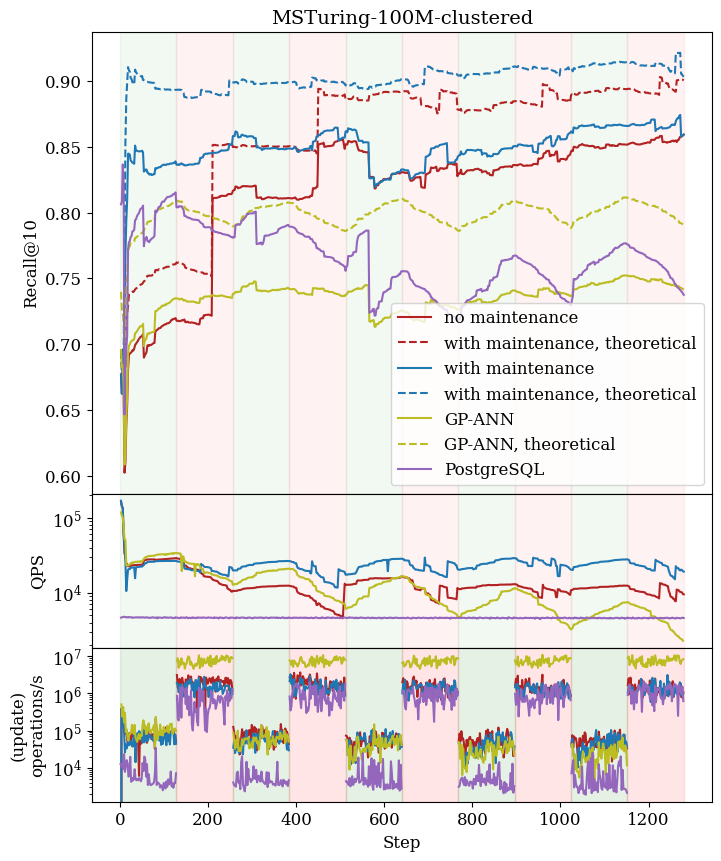

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0})

ax1.set_title("MSTuring-100M-clustered")
ax1.plot(
    surge_msturing100Mclusteredt10000[
                  (surge_msturing100Mclusteredt10000["mode"] == mode) &
                  (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_msturing100Mclusteredt10000[
                  (surge_msturing100Mclusteredt10000["mode"] == mode) &
                  (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
                 ]["recall@10"],
    label=f"{no_rebuilds_label}", color=no_rebuilds_color
)

ax1.plot(
    surge_msturing100Mclusteredt10000[
                  (surge_msturing100Mclusteredt10000["mode"] == mode) &
                  (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_msturing100Mclusteredt10000[
                  (surge_msturing100Mclusteredt10000["mode"] == mode) &
                  (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
                 ]["theoretical_recall@10"],
    label=f"{rebuilds_label}, theoretical", color=no_rebuilds_color, ls="--"
)

ax1.plot(
    surge_msturing100Mclusteredt6000[
                  (surge_msturing100Mclusteredt6000["mode"] == mode) &
                  (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
                 ]["step"],
    surge_msturing100Mclusteredt6000[
                  (surge_msturing100Mclusteredt6000["mode"] == mode) &
                  (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
                 ]["recall@10"],
    label=f"{rebuilds_label}", color=rebuilds_color
)

# ax1.scatter(
#     surge_msturing100Mclusteredt6000[
#             (surge_msturing100Mclusteredt6000["operation"] == "rebuild")
#             ]["step"], 
#             surge_msturing100Mclusteredt6000[
#             (surge_msturing100Mclusteredt6000["operation"] == "rebuild")
#             ]["recall@10"], marker=REBUILD_MARKER,
#             color=no_rebuilds_color, s=REBUILD_SIZE, linewidths=REBUILD_LW, zorder=4
# )

ax1.plot(
    surge_msturing100Mclusteredt6000[
                  (surge_msturing100Mclusteredt6000["mode"] == mode) &
                  (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
                 ]["step"],
    surge_msturing100Mclusteredt6000[
                  (surge_msturing100Mclusteredt6000["mode"] == mode) &
                  (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
                 ]["theoretical_recall@10"],
    label=f"{rebuilds_label}, theoretical", color=rebuilds_color, ls="--"
)

ax1.plot(
    gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["nprobe"] == gpann_param)
    ]["step"],
    gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["nprobe"] == gpann_param)
    ]["recall@10"],
    label="GP-ANN", color="C8"
)

ax1.plot(
    gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["nprobe"] == gpann_param)
    ]["step"],
    gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["nprobe"] == gpann_param)
    ]["theoretical_recall"],
    label="GP-ANN, theoretical", color="C8", ls="--"
)

ax1.plot(
    postgres_msturing100Mclustered[
        (postgres_msturing100Mclustered["operation"] == "search")
    ]["step"],
    postgres_msturing100Mclustered[
        (postgres_msturing100Mclustered["operation"] == "search")
    ]["recall_at_k"],
    label="PostgreSQL", color=postgres_color
)

ax1.set_ylabel("Recall@10")
ax1.set_xlabel("Step")

#####################

ax2.plot(
    surge_msturing100Mclusteredt10000[
                  (surge_msturing100Mclusteredt10000["mode"] == mode) &
                  (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_msturing100Mclusteredt10000[
                  (surge_msturing100Mclusteredt10000["mode"] == mode) &
                  (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
                 ]["throughput"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(
    surge_msturing100Mclusteredt6000[
                  (surge_msturing100Mclusteredt6000["mode"] == mode) &
                  (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
                 ]["step"],
    surge_msturing100Mclusteredt6000[
                  (surge_msturing100Mclusteredt6000["mode"] == mode) &
                  (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
                 ]["throughput"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["nprobe"] == gpann_param)
    ]["step"],
    gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["nprobe"] == gpann_param)
    ]["qps_or_throughput"],
    label="GP-ANN", color="C8"
)

ax2.plot(
    postgres_msturing100Mclustered[
        (postgres_msturing100Mclustered["operation"] == "search")
    ]["step"],
    postgres_msturing100Mclustered[
        (postgres_msturing100Mclustered["operation"] == "search")
    ]["qps"],
    label="PostgreSQL", color=postgres_color
)


ax2.set_yscale("log")
ax2.set_ylabel("QPS")
ax2.set_xlabel("Step")

#####################
ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)


# plot insert throughput, don't connect across the delete phases (in red)
# store phase boundaries in a list and use it to break the lines
phase_boundaries = [0, 128, 256, 384, 512, 640, 768, 896, 1024, 1152, 1280]

for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_msturing100Mclusteredt10000[
        (surge_msturing100Mclusteredt10000["operation"] == "insert") &
        (surge_msturing100Mclusteredt10000["step"] >= start) &
        (surge_msturing100Mclusteredt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,  # only label the first segment
            color=no_rebuilds_color
        )

# plot deletes in the same way, offset to delete phases (in red)
for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_msturing100Mclusteredt10000[
        (surge_msturing100Mclusteredt10000["operation"] == "delete") &
        (surge_msturing100Mclusteredt10000["step"] >= start) &
        (surge_msturing100Mclusteredt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,  # only label the first segment
            color=no_rebuilds_color,
            # ls="--"
        )


########surge rebuilding
for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_msturing100Mclusteredt6000[
        (surge_msturing100Mclusteredt6000["operation"] == "insert") &
        (surge_msturing100Mclusteredt6000["step"] >= start) &
        (surge_msturing100Mclusteredt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,  # only label the first segment
            color=rebuilds_color
        )

# plot deletes in the same way, offset to delete phases (in red)
for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_msturing100Mclusteredt6000[
        (surge_msturing100Mclusteredt6000["operation"] == "delete") &
        (surge_msturing100Mclusteredt6000["step"] >= start) &
        (surge_msturing100Mclusteredt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,  # only label the first segment
            color=rebuilds_color,
            # ls="--"
        )

############### gpann

# gpann_msturing100Mclustered[gpann_msturing100Mclustered["operation"]=='INSERT']
for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["operation"] == "INSERT") &
        (gpann_msturing100Mclustered["step"] >= start) &
        (gpann_msturing100Mclustered["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,  # only label the first segment
            color='C8'
        )

# plot deletes in the same way, offset to delete phases (in red)
for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = gpann_msturing100Mclustered[
        (gpann_msturing100Mclustered["operation"] == "DELETE") &
        (gpann_msturing100Mclustered["step"] >= start) &
        (gpann_msturing100Mclustered["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,  # only label the first segment
            color='C8',
            # ls="--"
        )

############### postgres
# postgres_msturing100Mclustered["update_throughput"]
for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = postgres_msturing100Mclustered[
        (postgres_msturing100Mclustered["operation"] == "insert") &
        (postgres_msturing100Mclustered["step"] >= start) &
        (postgres_msturing100Mclustered["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps"],
            label="PostgreSQL" if i == 0 else None,  # only label the first segment
            color=postgres_color
        )

# plot deletes in the same way, offset to delete phases (in red)
for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = postgres_msturing100Mclustered[
        (postgres_msturing100Mclustered["operation"] == "delete") &
        (postgres_msturing100Mclustered["step"] >= start) &
        (postgres_msturing100Mclustered["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps"],
            label="PostgreSQL" if i == 0 else None,  # only label the first segment
            color=postgres_color,
            # ls="--"
        )

ax3.set_yscale("log")
ax3.set_ylabel("(update)\noperations/s")
ax3.set_xlabel("Step")

# ax3.plot(
#     surge_msturing100Mclusteredt10000[
#                   (surge_msturing100Mclusteredt10000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
#                  ]["step"],
#     surge_msturing100Mclusteredt10000[
#                   (surge_msturing100Mclusteredt10000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
#                  ]["avg_parts_searched"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax3.plot(
#     surge_msturing100Mclusteredt6000[
#                   (surge_msturing100Mclusteredt6000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
#                  ]["step"],
#     surge_msturing100Mclusteredt6000[
#                   (surge_msturing100Mclusteredt6000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt6000["param"] == rebuild_param)
#                  ]["avg_parts_searched"],
#     label=rebuilds_label, color=rebuilds_color
# )


# ax3.plot(
#     gpann_msturing100Mclustered[
#         (gpann_msturing100Mclustered["nprobe"] == gpann_param)
#     ]["step"],
#     gpann_msturing100Mclustered[
#         (gpann_msturing100Mclustered["nprobe"] == gpann_param)
#     ]["nprobe"],
#     label="GP-ANN", color="C8"
# )

# ax3.plot(
#     surge_msturing100Mclusteredt10000[
#                   (surge_msturing100Mclusteredt10000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt10000["param"] == param)
#                  ]["step"],
#     surge_msturing100Mclusteredt10000[
#                   (surge_msturing100Mclusteredt10000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt10000["param"] == param)
#                  ]["gini"],
#     label=no_rebuilds_label, color=no_rebuilds_color
# )

# ax3.plot(
#     surge_msturing100Mclusteredt6000[
#                   (surge_msturing100Mclusteredt6000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt6000["param"] == param)
#                  ]["step"],
#     surge_msturing100Mclusteredt6000[
#                   (surge_msturing100Mclusteredt6000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt6000["param"] == param)
#                  ]["gini"],
#     label=rebuilds_label, color=rebuilds_color
# )


# ax3.plot(
#     gpann_msturing100Mclustered[
#         (gpann_msturing100Mclustered["nprobe"] == gpann_param)
#     ]["step"],
#     gpann_msturing100Mclustered[
#         (gpann_msturing100Mclustered["nprobe"] == gpann_param)
#     ]["gini"],
#     label="GP-ANN", color="C8"
# )

########################## rebuild time bars
# ax4.bar(
#     surge_msturing100Mclusteredt6000[
#         surge_msturing100Mclusteredt6000["operation"] == "rebuild"
#     ]["step"],
#     surge_msturing100Mclusteredt6000[
#         surge_msturing100Mclusteredt6000["operation"] == "rebuild"
#     ]["dorebuild_wall_s"],
#     label="delta rebuild", color=rebuilds_color, width=20
# )

# ax4.bar(
#     surge_msturing100Mclusteredt6000[
#         (surge_msturing100Mclusteredt6000["operation"] == "rebuild") &
#         (surge_msturing100Mclusteredt6000["rebuild_type"] == "full")
#     ]["step"],
#     surge_msturing100Mclusteredt6000[
#         (surge_msturing100Mclusteredt6000["operation"] == "rebuild") &
#         (surge_msturing100Mclusteredt6000["rebuild_type"] == "full")
#     ]["dorebuild_wall_s"],
#     label="full rebuild", color=rebuilds_color, width=20, hatch="//"
# )

# ax4.legend()
# ax4.set_ylabel("Rebuild Time (s)")

########################## imbalance
# ax4.plot(surge_msturing100Mclusteredt10000[
#             (surge_msturing100Mclusteredt10000["mode"] == mode) &
#             (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)]["step"],
#         surge_msturing100Mclusteredt10000[
#                   (surge_msturing100Mclusteredt10000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt10000["param"] == no_rebuild_param)
#                  ]["gini"],
#     label=f"{no_rebuilds_label}", color=no_rebuilds_color
# )

# ax4.plot(surge_msturing100Mclusteredt6000[
#                   (surge_msturing100Mclusteredt6000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt6000["param"] == no_rebuild_param)
#                  ]["step"],
#         surge_msturing100Mclusteredt6000[
#                   (surge_msturing100Mclusteredt6000["mode"] == mode) &
#                   (surge_msturing100Mclusteredt6000["param"] == no_rebuild_param)
#                  ]["gini"],
#     label=f"{rebuilds_label}", color=rebuilds_color
# )
# ax4.plot(
#     gpann_msturing100Mclustered[
#         (gpann_msturing100Mclustered["nprobe"] == gpann_param)
#     ]["step"],
#     gpann_msturing100Mclustered[
#         (gpann_msturing100Mclustered["nprobe"] == gpann_param)
#     ]["gini"],
#     label="GP-ANN", color="C8"
# )
# ax4.plot(
#     postgres_msturing100Mclustered[
#         (postgres_msturing100Mclustered["operation"] == "search")
#     ]["step"],
#     postgres_msturing100Mclustered[
#         (postgres_msturing100Mclustered["operation"] == "search")
#     ]["gini"],
#     label="PostgreSQL", color=postgres_color
# )


##########################
# color in insert/delete phases
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)

ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)

# ax4.set_ylabel("Imbalance (Gini)")
# ax4.set_xlabel("Step")

ax1.legend()

# MSTuring-100M-shift

In [19]:
surge_msturing100Mshiftt10000_path = "/users/dkhimey/surge/results/msturing-100M-shift_t10000-rebuildsbroken/results.csv"
surge_msturing100Mshiftt10000 = pd.read_csv(surge_msturing100Mshiftt10000_path)
surge_msturing100Mshiftt10000["gini"] = surge_msturing100Mshiftt10000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

surge_msturing100Mshiftt6000_path = "/users/dkhimey/surge/results/msturing-100M-shift_t6000/results.csv"
surge_msturing100Mshiftt6000 = pd.read_csv(surge_msturing100Mshiftt6000_path)
surge_msturing100Mshiftt6000["gini"] = surge_msturing100Mshiftt6000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

gpann_msturing100Mshift = pd.read_csv("/dataset/gp-ann-inserts/results/msturing_ef200/msturing100Mshift_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing100Mshift["gini"] = gpann_msturing100Mshift[gpann_shard_cols].apply(lambda row: gini(row.values), axis=1)


In [20]:
mode = "RecallTarget"
rebuild_param = .9
no_rebuild_param = .9
gpann_param = 5

surge_msturing100Mshiftt6000 = remove_weird_throughput_measurements(surge_msturing100Mshiftt6000, mode, rebuild_param)
surge_msturing100Mshiftt10000 = remove_weird_throughput_measurements(surge_msturing100Mshiftt10000, mode, no_rebuild_param)
gpann_msturing100Mshift = remove_weird_throughput_measurements_gpann(gpann_msturing100Mshift, gpann_param)


surge_msturing100Mshiftt6000 = remove_duplicate_steps(surge_msturing100Mshiftt6000)
surge_msturing100Mshiftt10000 = remove_duplicate_steps(surge_msturing100Mshiftt10000)

In [23]:
stats_surge_msturing100Mshiftt10000 = get_timing_stats(surge_msturing100Mshiftt10000, routing_mode="RecallTarget", routing_param=.9)
print(stats_surge_msturing100Mshiftt10000['summary_str'])

stats_surge_msturing100Mshiftt6000 = get_timing_stats(surge_msturing100Mshiftt6000, routing_mode="RecallTarget", routing_param=.9)
print(stats_surge_msturing100Mshiftt6000['summary_str'])

stats_gpann_msturing100Mshift = get_timing_stats_gpann(gpann_msturing100Mshift, nprobe=9)
print(stats_gpann_msturing100Mshift["summary_str"])


Timing Statistics: SURGE
Operation       Time (s)        Percentage     
---------------------------------------------
delete                 62.72s           1.4%
insert               1857.58s          40.6%
rebuild              2551.23s          55.7%
search                107.32s           2.3%
---------------------------------------------
TOTAL                4578.85s         100.0%

'Average Recall@10 (mode=RecallTarget, param=0.9)':<50       0.7395


Timing Statistics: SURGE
Operation       Time (s)        Percentage     
---------------------------------------------
delete                 62.21s           0.7%
insert               2059.19s          22.7%
rebuild              6658.62s          73.4%
search                286.22s           3.2%
---------------------------------------------
TOTAL                9066.23s         100.0%

'Average Recall@10 (mode=RecallTarget, param=0.9)':<50       0.8252


Timing Statistics: GP-ANN
Operation       Time (s)        Percentage     
---

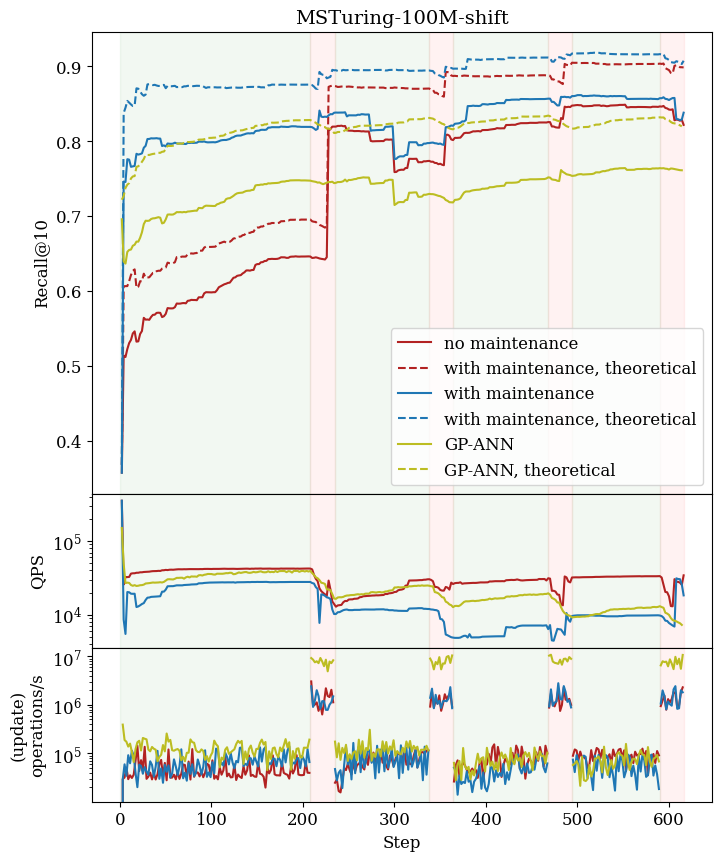

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0})

ax1.set_title("MSTuring-100M-shift")
ax1.plot(
    surge_msturing100Mshiftt10000[
                  (surge_msturing100Mshiftt10000["mode"] == mode) &
                  (surge_msturing100Mshiftt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_msturing100Mshiftt10000[
                  (surge_msturing100Mshiftt10000["mode"] == mode) &
                  (surge_msturing100Mshiftt10000["param"] == no_rebuild_param)
                 ]["recall@10"],
    label=f"{no_rebuilds_label}", color=no_rebuilds_color
)

ax1.plot(
    surge_msturing100Mshiftt10000[
                  (surge_msturing100Mshiftt10000["mode"] == mode) &
                  (surge_msturing100Mshiftt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_msturing100Mshiftt10000[
                  (surge_msturing100Mshiftt10000["mode"] == mode) &
                  (surge_msturing100Mshiftt10000["param"] == no_rebuild_param)
                 ]["theoretical_recall@10"],
    label=f"{rebuilds_label}, theoretical", color=no_rebuilds_color, ls="--"
)

ax1.plot(
    surge_msturing100Mshiftt6000[
                  (surge_msturing100Mshiftt6000["mode"] == mode) &
                  (surge_msturing100Mshiftt6000["param"] == rebuild_param)
                 ]["step"],
    surge_msturing100Mshiftt6000[
                  (surge_msturing100Mshiftt6000["mode"] == mode) &
                  (surge_msturing100Mshiftt6000["param"] == rebuild_param)
                 ]["recall@10"],
    label=f"{rebuilds_label}", color=rebuilds_color
)

ax1.plot(
    surge_msturing100Mshiftt6000[
                  (surge_msturing100Mshiftt6000["mode"] == mode) &
                  (surge_msturing100Mshiftt6000["param"] == rebuild_param)
                 ]["step"],
    surge_msturing100Mshiftt6000[
                  (surge_msturing100Mshiftt6000["mode"] == mode) &
                  (surge_msturing100Mshiftt6000["param"] == rebuild_param)
                 ]["theoretical_recall@10"],
    label=f"{rebuilds_label}, theoretical", color=rebuilds_color, ls="--"
)

ax1.plot(
    gpann_msturing100Mshift[
        (gpann_msturing100Mshift["nprobe"] == gpann_param)
    ]["step"],
    gpann_msturing100Mshift[
        (gpann_msturing100Mshift["nprobe"] == gpann_param)
    ]["recall@10"],
    label="GP-ANN", color="C8"
)

ax1.plot(
    gpann_msturing100Mshift[
        (gpann_msturing100Mshift["nprobe"] == gpann_param)
    ]["step"],
    gpann_msturing100Mshift[
        (gpann_msturing100Mshift["nprobe"] == gpann_param)
    ]["theoretical_recall"],
    label="GP-ANN, theoretical", color="C8", ls="--"
)

ax1.set_ylabel("Recall@10")
ax1.set_xlabel("Step")

#####################

ax2.plot(
    surge_msturing100Mshiftt10000[
                  (surge_msturing100Mshiftt10000["mode"] == mode) &
                  (surge_msturing100Mshiftt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_msturing100Mshiftt10000[
                  (surge_msturing100Mshiftt10000["mode"] == mode) &
                  (surge_msturing100Mshiftt10000["param"] == no_rebuild_param)
                 ]["throughput"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(
    surge_msturing100Mshiftt6000[
                  (surge_msturing100Mshiftt6000["mode"] == mode) &
                  (surge_msturing100Mshiftt6000["param"] == rebuild_param)
                 ]["step"],
    surge_msturing100Mshiftt6000[
                  (surge_msturing100Mshiftt6000["mode"] == mode) &
                  (surge_msturing100Mshiftt6000["param"] == rebuild_param)
                 ]["throughput"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    gpann_msturing100Mshift[
        (gpann_msturing100Mshift["nprobe"] == gpann_param)
    ]["step"],
    gpann_msturing100Mshift[
        (gpann_msturing100Mshift["nprobe"] == gpann_param)
    ]["qps_or_throughput"],
    label="GP-ANN", color="C8"
)

ax2.set_yscale("log")
ax2.set_ylabel("QPS")
ax2.set_xlabel("Step")

#####################
# ax3.axvspan(0, 208, color="green", alpha=0.05)
# ax3.axvspan(208, 235, color="red", alpha=0.05)
# ax3.axvspan(235, 338, color="green", alpha=0.05)
# ax3.axvspan(338, 364, color="red", alpha=0.05)
# ax3.axvspan(364, 468, color="green", alpha=0.05)
# ax3.axvspan(468, 494, color="red", alpha=0.05)
# ax3.axvspan(494, 590, color="green", alpha=0.05)
# ax3.axvspan(590, 616, color="red", alpha=0.05)

phase_boundaries = [0, 208, 235, 338, 364, 468, 494, 590, 616]

for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_msturing100Mshiftt10000[
        (surge_msturing100Mshiftt10000["operation"] == "insert") &
        (surge_msturing100Mshiftt10000["step"] >= start) &
        (surge_msturing100Mshiftt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,
            color=no_rebuilds_color
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_msturing100Mshiftt10000[
        (surge_msturing100Mshiftt10000["operation"] == "delete") &
        (surge_msturing100Mshiftt10000["step"] >= start) &
        (surge_msturing100Mshiftt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,
            color=no_rebuilds_color
        )

########surge rebuilding
for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_msturing100Mshiftt6000[
        (surge_msturing100Mshiftt6000["operation"] == "insert") &
        (surge_msturing100Mshiftt6000["step"] >= start) &
        (surge_msturing100Mshiftt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,
            color=rebuilds_color
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_msturing100Mshiftt6000[
        (surge_msturing100Mshiftt6000["operation"] == "delete") &
        (surge_msturing100Mshiftt6000["step"] >= start) &
        (surge_msturing100Mshiftt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,
            color=rebuilds_color
        )

############### gpann
for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = gpann_msturing100Mshift[
        (gpann_msturing100Mshift["operation"] == "INSERT") &
        (gpann_msturing100Mshift["step"] >= start) &
        (gpann_msturing100Mshift["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,
            color='C8'
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = gpann_msturing100Mshift[
        (gpann_msturing100Mshift["operation"] == "DELETE") &
        (gpann_msturing100Mshift["step"] >= start) &
        (gpann_msturing100Mshift["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,
            color='C8'
        )

ax3.set_yscale("log")
ax3.set_ylabel("(update)\noperations/s")
ax3.set_xlabel("Step")

##########################
# color in insert/delete phases
ax1.axvspan(0, 208, color="green", alpha=0.05)
ax1.axvspan(208, 235, color="red", alpha=0.05)
ax1.axvspan(235, 338, color="green", alpha=0.05)
ax1.axvspan(338, 364, color="red", alpha=0.05)
ax1.axvspan(364, 468, color="green", alpha=0.05)
ax1.axvspan(468, 494, color="red", alpha=0.05)
ax1.axvspan(494, 590, color="green", alpha=0.05)
ax1.axvspan(590, 616, color="red", alpha=0.05)

ax2.axvspan(0, 208, color="green", alpha=0.05)
ax2.axvspan(208, 235, color="red", alpha=0.05)
ax2.axvspan(235, 338, color="green", alpha=0.05)
ax2.axvspan(338, 364, color="red", alpha=0.05)
ax2.axvspan(364, 468, color="green", alpha=0.05)
ax2.axvspan(468, 494, color="red", alpha=0.05)
ax2.axvspan(494, 590, color="green", alpha=0.05)
ax2.axvspan(590, 616, color="red", alpha=0.05)

ax3.axvspan(0, 208, color="green", alpha=0.05)
ax3.axvspan(208, 235, color="red", alpha=0.05)
ax3.axvspan(235, 338, color="green", alpha=0.05)
ax3.axvspan(338, 364, color="red", alpha=0.05)
ax3.axvspan(364, 468, color="green", alpha=0.05)
ax3.axvspan(468, 494, color="red", alpha=0.05)
ax3.axvspan(494, 590, color="green", alpha=0.05)
ax3.axvspan(590, 616, color="red", alpha=0.05)

ax1.legend()

# SIFT-100M-clustered

In [26]:
surge_bigann100Mclusteredt10000_path = "/users/dkhimey/surge/results/bigann-100M-clustered_t10000-rebuildsbroken/results.csv"
surge_bigann100Mclusteredt10000 = pd.read_csv(surge_bigann100Mclusteredt10000_path)
surge_bigann100Mclusteredt10000["gini"] = surge_bigann100Mclusteredt10000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

surge_bigann100Mclusteredt6000_path = "/users/dkhimey/surge/results/bigann-100M-clustered_t6000/results.csv"
surge_bigann100Mclusteredt6000 = pd.read_csv(surge_bigann100Mclusteredt6000_path)
surge_bigann100Mclusteredt6000["gini"] = surge_bigann100Mclusteredt6000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

gpann_bigann100Mclustered = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/gpann_partitions/bigann100Mclustered_runbook_results_nprobe_with_theo_sweep_final.csv")
gpann_bigann100Mclustered["gini"] = gpann_bigann100Mclustered[gpann_shard_cols].apply(lambda row: gini(row.values), axis=1)


In [27]:
mode = "RecallTarget"
param = .9
gpann_param = 5

surge_bigann100Mclusteredt6000 = remove_weird_throughput_measurements(surge_bigann100Mclusteredt6000, mode, param)
surge_bigann100Mclusteredt10000 = remove_weird_throughput_measurements(surge_bigann100Mclusteredt10000, mode, param)
gpann_bigann100Mclustered = remove_weird_throughput_measurements_gpann(gpann_bigann100Mclustered, gpann_param)

surge_bigann100Mclusteredt6000 = remove_duplicate_steps(surge_bigann100Mclusteredt6000)
surge_bigann100Mclusteredt10000 = remove_duplicate_steps(surge_bigann100Mclusteredt10000)

In [28]:
stats_surge_bigann100Mclusteredt10000 = get_timing_stats(surge_bigann100Mclusteredt10000, routing_mode="NProbe", routing_param=8)
print(stats_surge_bigann100Mclusteredt10000['summary_str'])

stats_surge_bigann100Mclusteredt6000 = get_timing_stats(surge_bigann100Mclusteredt6000, routing_mode="NProbe", routing_param=6)
print(stats_surge_bigann100Mclusteredt6000['summary_str'])

stats_gpann_bigann100Mclustered = get_timing_stats_gpann(gpann_bigann100Mclustered, nprobe=9)
print(stats_gpann_bigann100Mclustered["summary_str"])


Timing Statistics: SURGE
Operation       Time (s)        Percentage     
---------------------------------------------
delete                 51.42s           1.3%
insert               3445.80s          88.0%
search                418.27s          10.7%
---------------------------------------------
TOTAL                3915.49s         100.0%

'Average Recall@10 (mode=NProbe, param=8)':<50       0.9908


Timing Statistics: SURGE
Operation       Time (s)        Percentage     
---------------------------------------------
delete                103.99s           1.0%
insert               3230.39s          31.8%
rebuild              6547.17s          64.4%
search                278.41s           2.7%
---------------------------------------------
TOTAL               10159.96s         100.0%

'Average Recall@10 (mode=NProbe, param=6)':<50       0.9852


Timing Statistics: GP-ANN
Operation       Time (s)        Percentage     
---------------------------------------------
BUILD             

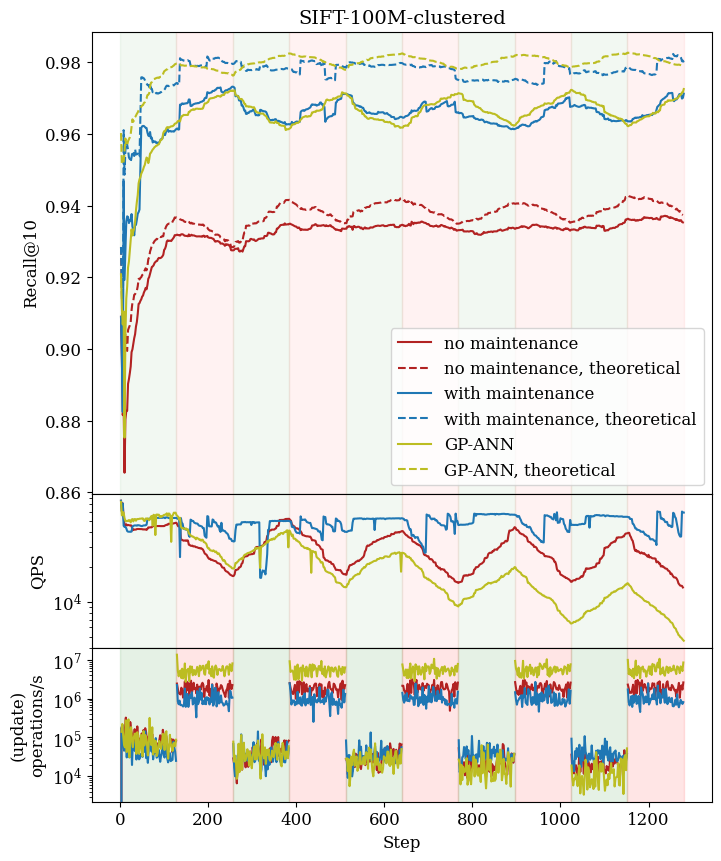

In [29]:
mode = "RecallTarget"
param = .9
gpann_param = 5

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0})

ax1.set_title("SIFT-100M-clustered")
ax1.plot(
    surge_bigann100Mclusteredt10000[
                  (surge_bigann100Mclusteredt10000["mode"] == mode) &
                  (surge_bigann100Mclusteredt10000["param"] == param)
                 ]["step"],
    surge_bigann100Mclusteredt10000[
                  (surge_bigann100Mclusteredt10000["mode"] == mode) &
                  (surge_bigann100Mclusteredt10000["param"] == param)
                 ]["recall@10"],
    label=f"{no_rebuilds_label}", color=no_rebuilds_color
)

ax1.plot(
    surge_bigann100Mclusteredt10000[
                  (surge_bigann100Mclusteredt10000["mode"] == mode) &
                  (surge_bigann100Mclusteredt10000["param"] == param)
                 ]["step"],
    surge_bigann100Mclusteredt10000[
                  (surge_bigann100Mclusteredt10000["mode"] == mode) &
                  (surge_bigann100Mclusteredt10000["param"] == param)
                 ]["theoretical_recall@10"],
    label=f"{no_rebuilds_label}, theoretical", color=no_rebuilds_color, ls="--"
)

ax1.plot(
    surge_bigann100Mclusteredt6000[
                  (surge_bigann100Mclusteredt6000["mode"] == mode) &
                  (surge_bigann100Mclusteredt6000["param"] == param)
                 ]["step"],
    surge_bigann100Mclusteredt6000[
                  (surge_bigann100Mclusteredt6000["mode"] == mode) &
                  (surge_bigann100Mclusteredt6000["param"] == param)
                 ]["recall@10"],
    label=f"{rebuilds_label}", color=rebuilds_color
)

ax1.plot(
    surge_bigann100Mclusteredt6000[
                  (surge_bigann100Mclusteredt6000["mode"] == mode) &
                  (surge_bigann100Mclusteredt6000["param"] == param)
                 ]["step"],
    surge_bigann100Mclusteredt6000[
                  (surge_bigann100Mclusteredt6000["mode"] == mode) &
                  (surge_bigann100Mclusteredt6000["param"] == param)
                 ]["theoretical_recall@10"],
    label=f"{rebuilds_label}, theoretical", color=rebuilds_color, ls="--"
)

ax1.plot(
    gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["nprobe"] == gpann_param)
    ]["step"],
    gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["nprobe"] == gpann_param)
    ]["recall@10"],
    label="GP-ANN", color="C8"
)

ax1.plot(
    gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["nprobe"] == gpann_param)
    ]["step"],
    gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["nprobe"] == gpann_param)
    ]["theoretical_recall"],
    label="GP-ANN, theoretical", color="C8", ls="--"
)

ax1.set_ylabel("Recall@10")
ax1.set_xlabel("Step")

#####################

ax2.plot(
    surge_bigann100Mclusteredt10000[
                  (surge_bigann100Mclusteredt10000["mode"] == mode) &
                  (surge_bigann100Mclusteredt10000["param"] == param)
                 ]["step"],
    surge_bigann100Mclusteredt10000[
                  (surge_bigann100Mclusteredt10000["mode"] == mode) &
                  (surge_bigann100Mclusteredt10000["param"] == param)
                 ]["throughput"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(
    surge_bigann100Mclusteredt6000[
                  (surge_bigann100Mclusteredt6000["mode"] == mode) &
                  (surge_bigann100Mclusteredt6000["param"] == param)
                 ]["step"],
    surge_bigann100Mclusteredt6000[
                  (surge_bigann100Mclusteredt6000["mode"] == mode) &
                  (surge_bigann100Mclusteredt6000["param"] == param)
                 ]["throughput"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["nprobe"] == gpann_param)
    ]["step"],
    gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["nprobe"] == gpann_param)
    ]["qps_or_throughput"],
    label="GP-ANN", color="C8"
)

ax2.set_yscale("log")
ax2.set_ylabel("QPS")
ax2.set_xlabel("Step")

#####################
ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)

phase_boundaries = [0, 128, 256, 384, 512, 640, 768, 896, 1024, 1152, 1280]

for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_bigann100Mclusteredt10000[
        (surge_bigann100Mclusteredt10000["operation"] == "insert") &
        (surge_bigann100Mclusteredt10000["step"] >= start) &
        (surge_bigann100Mclusteredt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,
            color=no_rebuilds_color
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_bigann100Mclusteredt10000[
        (surge_bigann100Mclusteredt10000["operation"] == "delete") &
        (surge_bigann100Mclusteredt10000["step"] >= start) &
        (surge_bigann100Mclusteredt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,
            color=no_rebuilds_color
        )

for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_bigann100Mclusteredt6000[
        (surge_bigann100Mclusteredt6000["operation"] == "insert") &
        (surge_bigann100Mclusteredt6000["step"] >= start) &
        (surge_bigann100Mclusteredt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,
            color=rebuilds_color
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_bigann100Mclusteredt6000[
        (surge_bigann100Mclusteredt6000["operation"] == "delete") &
        (surge_bigann100Mclusteredt6000["step"] >= start) &
        (surge_bigann100Mclusteredt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,
            color=rebuilds_color
        )

for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["operation"] == "INSERT") &
        (gpann_bigann100Mclustered["step"] >= start) &
        (gpann_bigann100Mclustered["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,
            color='C8'
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = gpann_bigann100Mclustered[
        (gpann_bigann100Mclustered["operation"] == "DELETE") &
        (gpann_bigann100Mclustered["step"] >= start) &
        (gpann_bigann100Mclustered["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,
            color='C8'
        )

ax3.set_yscale("log")
ax3.set_ylabel("(update)\noperations/s")
ax3.set_xlabel("Step")

##########################
ax1.axvspan(0, 128, color="green", alpha=0.05)
ax1.axvspan(128, 256, color="red", alpha=0.05)
ax1.axvspan(256, 384, color="green", alpha=0.05)
ax1.axvspan(384, 512, color="red", alpha=0.05)
ax1.axvspan(512, 640, color="green", alpha=0.05)
ax1.axvspan(640, 768, color="red", alpha=0.05)
ax1.axvspan(768, 896, color="green", alpha=0.05)
ax1.axvspan(896, 1024, color="red", alpha=0.05)
ax1.axvspan(1024, 1152, color="green", alpha=0.05)
ax1.axvspan(1152, 1280, color="red", alpha=0.05)

ax2.axvspan(0, 128, color="green", alpha=0.05)
ax2.axvspan(128, 256, color="red", alpha=0.05)
ax2.axvspan(256, 384, color="green", alpha=0.05)
ax2.axvspan(384, 512, color="red", alpha=0.05)
ax2.axvspan(512, 640, color="green", alpha=0.05)
ax2.axvspan(640, 768, color="red", alpha=0.05)
ax2.axvspan(768, 896, color="green", alpha=0.05)
ax2.axvspan(896, 1024, color="red", alpha=0.05)
ax2.axvspan(1024, 1152, color="green", alpha=0.05)
ax2.axvspan(1152, 1280, color="red", alpha=0.05)

ax3.axvspan(0, 128, color="green", alpha=0.05)
ax3.axvspan(128, 256, color="red", alpha=0.05)
ax3.axvspan(256, 384, color="green", alpha=0.05)
ax3.axvspan(384, 512, color="red", alpha=0.05)
ax3.axvspan(512, 640, color="green", alpha=0.05)
ax3.axvspan(640, 768, color="red", alpha=0.05)
ax3.axvspan(768, 896, color="green", alpha=0.05)
ax3.axvspan(896, 1024, color="red", alpha=0.05)
ax3.axvspan(1024, 1152, color="green", alpha=0.05)
ax3.axvspan(1152, 1280, color="red", alpha=0.05)

ax1.legend()

# SIFT-100M-shift

In [30]:
# surge_bigann100Mshiftt10000_path = "/users/dkhimey/surge/results/bigann-100M-shift_t10000/results.csv"
# surge_bigann100Mshiftt10000 = pd.read_csv(surge_bigann100Mshiftt10000_path)
# surge_bigann100Mshiftt10000["gini"] = surge_bigann100Mshiftt10000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

surge_bigann100Mshiftt6000_path = "/users/dkhimey/surge/results/bigann-100M-shift_t6000/results.csv"
surge_bigann100Mshiftt6000 = pd.read_csv(surge_bigann100Mshiftt6000_path)
surge_bigann100Mshiftt6000["gini"] = surge_bigann100Mshiftt6000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

surge_bigann100Mshiftt10000_path = "/users/dkhimey/surge/results/bigann-100M-shift_t10000-rebuildsbroken/results.csv"
surge_bigann100Mshiftt10000 = pd.read_csv(surge_bigann100Mshiftt10000_path)
surge_bigann100Mshiftt10000["gini"] = surge_bigann100Mshiftt10000[surge_shard_cols].apply(lambda row: gini(row.values), axis=1)

gpann_bigann100Mshift= pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-shift/gpann_partitions/bigann100Mshift_runbook_results_nprobe_with_theo_sweep.csv")
gpann_bigann100Mshift["gini"] = gpann_bigann100Mshift[gpann_shard_cols].apply(lambda row: gini(row.values), axis=1)


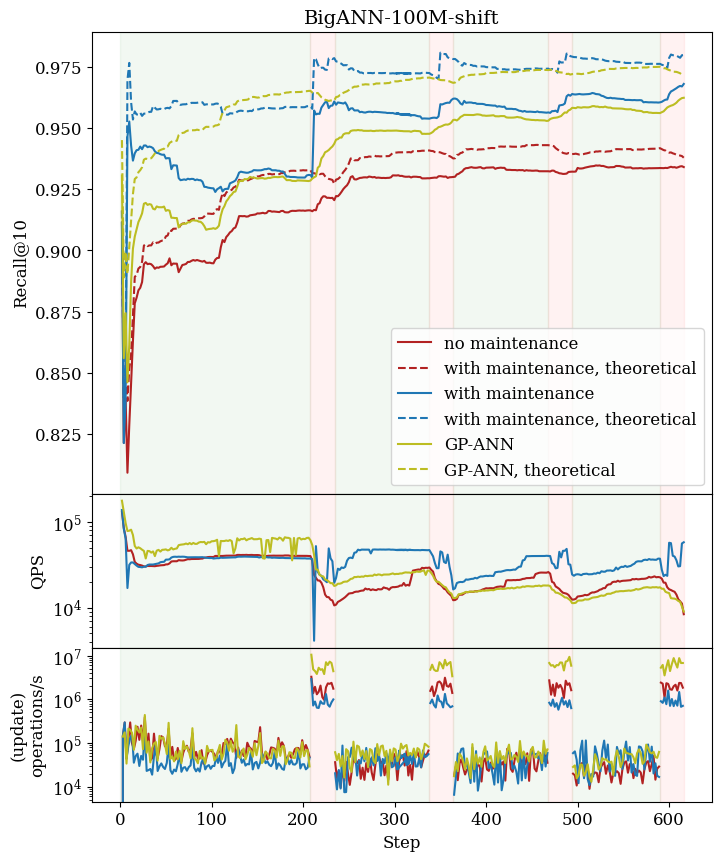

In [ ]:
mode = "RecallTarget"
rebuild_param = .9
no_rebuild_param = .9
gpann_param = 5

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0})

ax1.set_title("SIFT-100M-shift")
ax1.plot(
    surge_bigann100Mshiftt10000[
                  (surge_bigann100Mshiftt10000["mode"] == mode) &
                  (surge_bigann100Mshiftt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_bigann100Mshiftt10000[
                  (surge_bigann100Mshiftt10000["mode"] == mode) &
                  (surge_bigann100Mshiftt10000["param"] == no_rebuild_param)
                 ]["recall@10"],
    label=f"{no_rebuilds_label}", color=no_rebuilds_color
)

ax1.plot(
    surge_bigann100Mshiftt10000[
                  (surge_bigann100Mshiftt10000["mode"] == mode) &
                  (surge_bigann100Mshiftt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_bigann100Mshiftt10000[
                  (surge_bigann100Mshiftt10000["mode"] == mode) &
                  (surge_bigann100Mshiftt10000["param"] == no_rebuild_param)
                 ]["theoretical_recall@10"],
    label=f"{rebuilds_label}, theoretical", color=no_rebuilds_color, ls="--"
)

ax1.plot(
    surge_bigann100Mshiftt6000[
                  (surge_bigann100Mshiftt6000["mode"] == mode) &
                  (surge_bigann100Mshiftt6000["param"] == rebuild_param)
                 ]["step"],
    surge_bigann100Mshiftt6000[
                  (surge_bigann100Mshiftt6000["mode"] == mode) &
                  (surge_bigann100Mshiftt6000["param"] == rebuild_param)
                 ]["recall@10"],
    label=f"{rebuilds_label}", color=rebuilds_color
)

ax1.plot(
    surge_bigann100Mshiftt6000[
                  (surge_bigann100Mshiftt6000["mode"] == mode) &
                  (surge_bigann100Mshiftt6000["param"] == rebuild_param)
                 ]["step"],
    surge_bigann100Mshiftt6000[
                  (surge_bigann100Mshiftt6000["mode"] == mode) &
                  (surge_bigann100Mshiftt6000["param"] == rebuild_param)
                 ]["theoretical_recall@10"],
    label=f"{rebuilds_label}, theoretical", color=rebuilds_color, ls="--"
)

ax1.plot(
    gpann_bigann100Mshift[
        (gpann_bigann100Mshift["nprobe"] == gpann_param)
    ]["step"],
    gpann_bigann100Mshift[
        (gpann_bigann100Mshift["nprobe"] == gpann_param)
    ]["recall@10"],
    label="GP-ANN", color="C8"
)

ax1.plot(
    gpann_bigann100Mshift[
        (gpann_bigann100Mshift["nprobe"] == gpann_param)
    ]["step"],
    gpann_bigann100Mshift[
        (gpann_bigann100Mshift["nprobe"] == gpann_param)
    ]["theoretical_recall"],
    label="GP-ANN, theoretical", color="C8", ls="--"
)

ax1.set_ylabel("Recall@10")
ax1.set_xlabel("Step")

#####################

ax2.plot(
    surge_bigann100Mshiftt10000[
                  (surge_bigann100Mshiftt10000["mode"] == mode) &
                  (surge_bigann100Mshiftt10000["param"] == no_rebuild_param)
                 ]["step"],
    surge_bigann100Mshiftt10000[
                  (surge_bigann100Mshiftt10000["mode"] == mode) &
                  (surge_bigann100Mshiftt10000["param"] == no_rebuild_param)
                 ]["throughput"],
    label=no_rebuilds_label, color=no_rebuilds_color
)

ax2.plot(
    surge_bigann100Mshiftt6000[
                  (surge_bigann100Mshiftt6000["mode"] == mode) &
                  (surge_bigann100Mshiftt6000["param"] == rebuild_param)
                 ]["step"],
    surge_bigann100Mshiftt6000[
                  (surge_bigann100Mshiftt6000["mode"] == mode) &
                  (surge_bigann100Mshiftt6000["param"] == rebuild_param)
                 ]["throughput"],
    label=rebuilds_label, color=rebuilds_color
)

ax2.plot(
    gpann_bigann100Mshift[
        (gpann_bigann100Mshift["nprobe"] == gpann_param)
    ]["step"],
    gpann_bigann100Mshift[
        (gpann_bigann100Mshift["nprobe"] == gpann_param)
    ]["qps_or_throughput"],
    label="GP-ANN", color="C8"
)

ax2.set_yscale("log")
ax2.set_ylabel("QPS")
ax2.set_xlabel("Step")

#####################
# ax3.axvspan(0, 208, color="green", alpha=0.05)
# ax3.axvspan(208, 245, color="red", alpha=0.05)
# ax3.axvspan(245, 338, color="green", alpha=0.05)
# ax3.axvspan(338, 364, color="red", alpha=0.05)
# ax3.axvspan(364, 468, color="green", alpha=0.05)
# ax3.axvspan(468, 494, color="red", alpha=0.05)
# ax3.axvspan(494, 590, color="green", alpha=0.05)
# ax3.axvspan(590, 616, color="red", alpha=0.05)

phase_boundaries = [0, 208, 235, 338, 364, 468, 494, 590, 616]

for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_bigann100Mshiftt10000[
        (surge_bigann100Mshiftt10000["operation"] == "insert") &
        (surge_bigann100Mshiftt10000["step"] >= start) &
        (surge_bigann100Mshiftt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,
            color=no_rebuilds_color
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_bigann100Mshiftt10000[
        (surge_bigann100Mshiftt10000["operation"] == "delete") &
        (surge_bigann100Mshiftt10000["step"] >= start) &
        (surge_bigann100Mshiftt10000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=no_rebuilds_label if i == 0 else None,
            color=no_rebuilds_color
        )

for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = surge_bigann100Mshiftt6000[
        (surge_bigann100Mshiftt6000["operation"] == "insert") &
        (surge_bigann100Mshiftt6000["step"] >= start) &
        (surge_bigann100Mshiftt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,
            color=rebuilds_color
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = surge_bigann100Mshiftt6000[
        (surge_bigann100Mshiftt6000["operation"] == "delete") &
        (surge_bigann100Mshiftt6000["step"] >= start) &
        (surge_bigann100Mshiftt6000["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["throughput"],
            label=rebuilds_label if i == 0 else None,
            color=rebuilds_color
        )

############### gpann
for i in range(len(phase_boundaries) - 1):
    start = phase_boundaries[i]
    end = phase_boundaries[i + 1]
    phase_data = gpann_bigann100Mshift[
        (gpann_bigann100Mshift["operation"] == "INSERT") &
        (gpann_bigann100Mshift["step"] >= start) &
        (gpann_bigann100Mshift["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,
            color='C8'
        )

for i in range(len(phase_boundaries) - 2):
    start = phase_boundaries[i+1]
    end = phase_boundaries[i + 2]
    phase_data = gpann_bigann100Mshift[
        (gpann_bigann100Mshift["operation"] == "DELETE") &
        (gpann_bigann100Mshift["step"] >= start) &
        (gpann_bigann100Mshift["step"] < end)
    ]
    if not phase_data.empty:
        ax3.plot(
            phase_data["step"],
            phase_data["qps_or_throughput"],
            label="GP-ANN" if i == 0 else None,
            color='C8'
        )

ax3.set_yscale("log")
ax3.set_ylabel("(update)\noperations/s")
ax3.set_xlabel("Step")

##########################
# color in insert/delete phases
ax1.axvspan(0, 208, color="green", alpha=0.05)
ax1.axvspan(208, 235, color="red", alpha=0.05)
ax1.axvspan(235, 338, color="green", alpha=0.05)
ax1.axvspan(338, 364, color="red", alpha=0.05)
ax1.axvspan(364, 468, color="green", alpha=0.05)
ax1.axvspan(468, 494, color="red", alpha=0.05)
ax1.axvspan(494, 590, color="green", alpha=0.05)
ax1.axvspan(590, 616, color="red", alpha=0.05)

ax2.axvspan(0, 208, color="green", alpha=0.05)
ax2.axvspan(208, 235, color="red", alpha=0.05)
ax2.axvspan(235, 338, color="green", alpha=0.05)
ax2.axvspan(338, 364, color="red", alpha=0.05)
ax2.axvspan(364, 468, color="green", alpha=0.05)
ax2.axvspan(468, 494, color="red", alpha=0.05)
ax2.axvspan(494, 590, color="green", alpha=0.05)
ax2.axvspan(590, 616, color="red", alpha=0.05)

ax3.axvspan(0, 208, color="green", alpha=0.05)
ax3.axvspan(208, 235, color="red", alpha=0.05)
ax3.axvspan(235, 338, color="green", alpha=0.05)
ax3.axvspan(338, 364, color="red", alpha=0.05)
ax3.axvspan(364, 468, color="green", alpha=0.05)
ax3.axvspan(468, 494, color="red", alpha=0.05)
ax3.axvspan(494, 590, color="green", alpha=0.05)
ax3.axvspan(590, 616, color="red", alpha=0.05)

ax1.legend()

In [ ]:
mode = "RecallTarget"
rebuild_param = .9
no_rebuild_param = .9
gpann_param = 5

surge_bigann100Mshiftt6000 = remove_weird_throughput_measurements(surge_bigann100Mshiftt6000, mode, rebuild_param)
surge_bigann100Mshiftt10000 = remove_weird_throughput_measurements(surge_bigann100Mshiftt10000, mode, no_rebuild_param)
gpann_bigann100Mshift = remove_weird_throughput_measurements_gpann(gpann_bigann100Mshift, gpann_param)

surge_bigann100Mshiftt6000 = remove_duplicate_steps(surge_bigann100Mshiftt6000)
surge_bigann100Mshiftt10000 = remove_duplicate_steps(surge_bigann100Mshiftt10000)

In [ ]:
stats_surge_bigann100Mshiftt10000 = get_timing_stats(surge_bigann100Mshiftt10000, routing_mode="NProbe", routing_param=8)
print(stats_surge_bigann100Mshiftt10000['summary_str'])

stats_surge_bigann100Mshiftt6000 = get_timing_stats(surge_bigann100Mshiftt6000, routing_mode="NProbe", routing_param=6)
print(stats_surge_bigann100Mshiftt6000['summary_str'])

stats_gpann_bigann100Mshift = get_timing_stats_gpann(gpann_bigann100Mshift, nprobe=9)
print(stats_gpann_bigann100Mshift["summary_str"])